In [1]:
# ==========================================
# WEALTHSIMPLE DIRECT INDEXING: TLH ENGINE
# ==========================================
# This notebook executes the Object-Oriented pipeline.
# It runs the daily historical simulation, stepping through time to execute 
# the Direct Indexing & Tax-Loss Harvesting strategy while strictly obeying 
# CRA tax regulations and dynamic Tracking Error constraints.

import warnings
warnings.filterwarnings('ignore') # Keep output clean for presentation

from c3_backtest_runner import TLHBacktester

In [2]:
# We run the simulation from 2019 to 2020. 
# This specific sub-period stress-tests the algorithm against the March 2020 COVID crash.
# It proves that the "Relative Risk Budgeting" (Dynamic TEV Multiplier) organically 
# expands the risk leash during VIX spikes, preventing the CVXPY solver from crashing 
# while aggressively harvesting pandemic-induced tax losses.

backtester = TLHBacktester(
    start_date='2019-01-01', 
    end_date='2020-12-31', 
    initial_capital=1_000_000.0
)

# Execute the daily state-machine loop
backtester.run_simulation()

Initializing Backtest Engine...
Loading Risk Model inputs from Phase A (Quant Infrastructure)...
Building daily return matrix for Ledoit-Wolf failsafe...
Loading Factor Exposures (X)...
Loading Factor Covariance Matrices (F)...
Loading Idiosyncratic Risk (Delta)...
Starting Simulation: 2019-01-01 to 2020-12-31
Total Trading Days: 505


Simulating Daily Trading: 100%|██████████| 505/505 [14:30<00:00,  1.72s/it]


Simulation Complete!



 INSTITUTIONAL TEARSHEET (Wealthsimple Direct Indexing)
Initial Capital (CAD):     $1,000,000.00
Final AUM (CAD):           $1,148,721.75
Pre-Tax Total Return:      14.87%
-------------------------------------------------
Total Losses Harvested:    $600,397.41
Estimated Tax Savings:     $159,105.31 CAD
Estimated Tax Alpha:       1591.1 bps



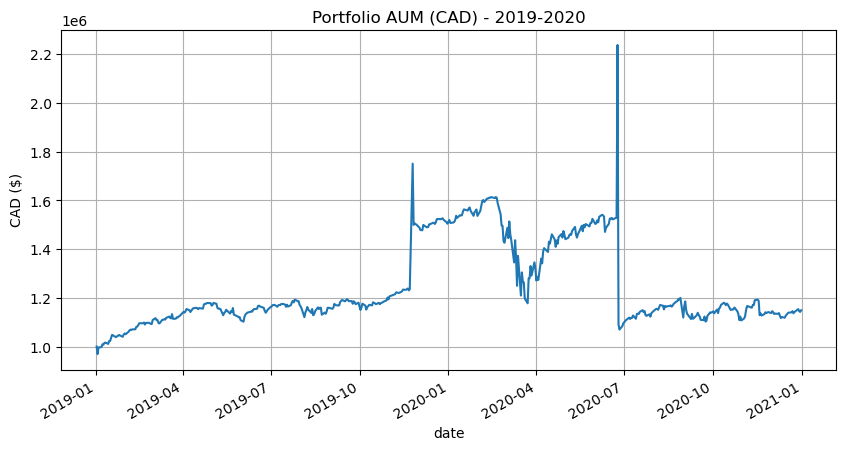

In [3]:
# Generate the Institutional Tearsheet and calculate estimated Tax Alpha
results_df = backtester.generate_tearsheet()

# AUM plot
import matplotlib.pyplot as plt
results_df['portfolio_aum_cad'].plot(figsize=(10, 5), title='Portfolio AUM (CAD) - 2019-2020', ylabel='CAD ($)')
plt.grid(True)
plt.show()

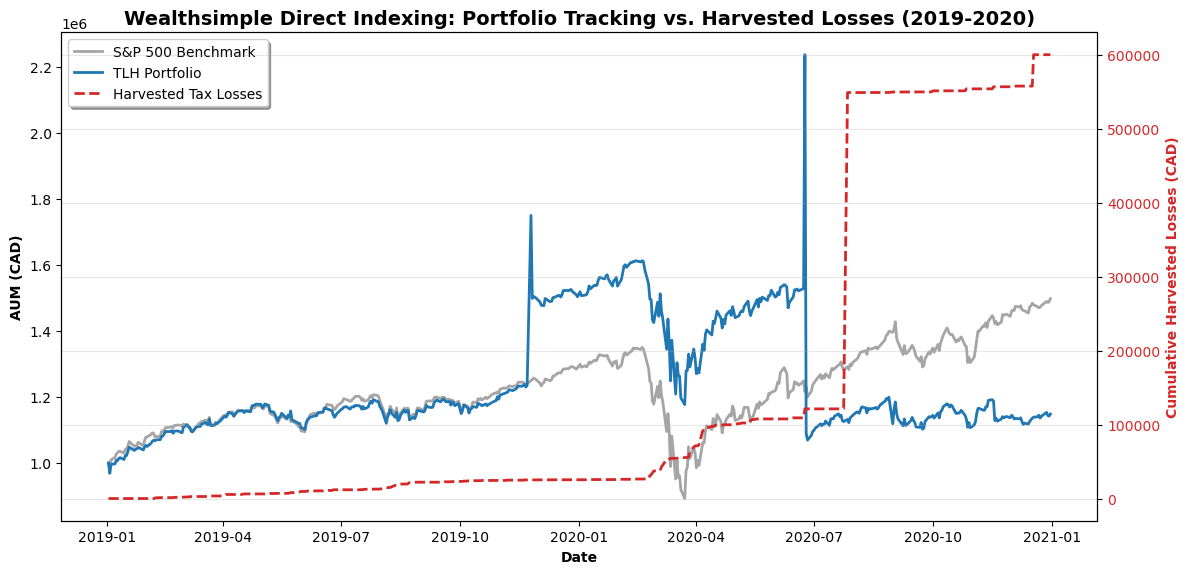

In [4]:
# ==========================================
# VISUALIZING THE TAX ALPHA & TRACKING ERROR
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the S&P 500 Daily Returns from your universe data
# (We take the mean just to get one daily value, since sprtrn is duplicated across rows)
sp500_returns = backtester.df_univ['sprtrn'].groupby('date').mean()

# 2. Calculate Cumulative Benchmark AUM starting at $1,000,000
# (Adding 1 to returns, taking cumulative product, multiplying by initial capital)
benchmark_aum = 1000000.0 * (1 + sp500_returns).cumprod()
# Realign to match the exact dates in our results
benchmark_aum = benchmark_aum.reindex(results_df.index).ffill()

# 3. Build the Dual-Axis Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Left Axis: AUM (Portfolio vs Benchmark) ---
color1 = '#1f77b4' # Portfolio Blue
color_bench = '#7f7f7f' # Benchmark Grey

ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('AUM (CAD)', fontweight='bold')

# Plot Benchmark first (so it stays in the background)
ax1.plot(results_df.index, benchmark_aum, color=color_bench, linewidth=2, linestyle='-', alpha=0.7, label='S&P 500 Benchmark')
# Plot Portfolio
ax1.plot(results_df.index, results_df['portfolio_aum_cad'], color=color1, linewidth=2, label='TLH Portfolio')

ax1.tick_params(axis='y')
ax1.set_title('Wealthsimple Direct Indexing: Portfolio Tracking vs. Harvested Losses (2019-2020)', fontsize=14, fontweight='bold')

# --- Right Axis: Cumulative Harvested Losses ---
ax2 = ax1.twinx()  
color2 = '#d62728' # Tax Alpha Red
ax2.set_ylabel('Cumulative Harvested Losses (CAD)', color=color2, fontweight='bold')

# Plot the Losses
ax2.plot(results_df.index, results_df['realized_losses_cad'], color=color2, linewidth=2, linestyle='--', label='Harvested Tax Losses')
ax2.tick_params(axis='y', labelcolor=color2)

# --- Legends & Formatting ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()